# Proyecto de Evaluación del Segundo Parcial
**Entrenamiento, validación y prueba de redes neuronales convolucionales para clasificación de imágenes médicas usando MedMNIST.**

**Autor:** Kristopher Vela Domínguez
**Institución:** Universidad de Xalapa

### 1. Carga y Exploración del Dataset
Se utiliza el dataset **BloodMNIST** (imágenes de células sanguíneas en formato RGB de 28x28).

Dataset: BLOODMNIST
Número de clases: 8
Diccionario de clases: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
Imágenes de entrenamiento: 11959
Imágenes de validación: 1712
Imágenes de prueba: 3421


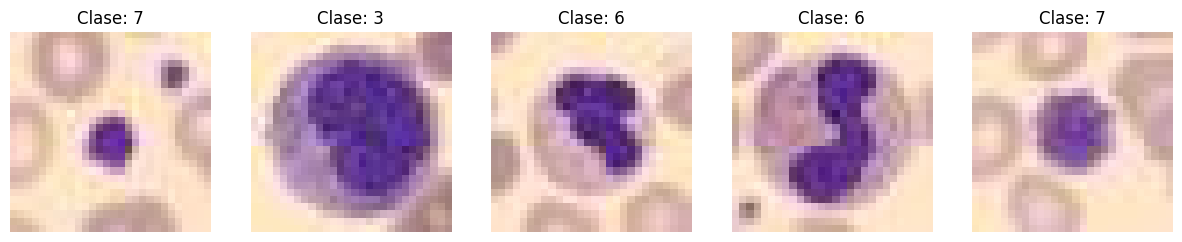

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO
from torch.utils.data import DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Configuración del Dataset (Regresamos a BloodMNIST)
data_flag = 'bloodmnist'
info = INFO[data_flag]
n_classes = len(info['label'])
DataClass = getattr(medmnist, info['python_class'])

print(f"Dataset: {data_flag.upper()}")
print(f"Número de clases: {n_classes}")
print(f"Diccionario de clases: {info['label']}")

# Descarga inicial para exploración
temp_dataset = DataClass(split='train', download=True)
print(f"Imágenes de entrenamiento: {info['n_samples']['train']}")
print(f"Imágenes de validación: {info['n_samples']['val']}")
print(f"Imágenes de prueba: {info['n_samples']['test']}")

# Visualización
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img, label = temp_dataset[i]
    axes[i].imshow(img)
    axes[i].set_title(f"Clase: {label[0]}")
    axes[i].axis('off')
plt.savefig('ejemplos_dataset.png', dpi=300, bbox_inches='tight')
plt.show()

### 2. Preparación de Datos
Normalización de imágenes RGB a tensores y configuración de los DataLoaders con tamaño de lote (batch size) de 64.

In [35]:
# Transformaciones (BloodMNIST ya es RGB nativo)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_dataset = DataClass(split='train', transform=transform, download=True)
val_dataset = DataClass(split='val', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### 3, 4 y 5. Modelos e Hiperparámetros
* **KrisNET:** CNN de diseño propio adaptada a 8 clases.
* **ResNet-50:** Transfer learning adaptando la capa de salida.
* **Épocas:** 20
* **Dropout:** 0.3
* **Learning Rate:** 0.001 (KrisNET), 0.0001 (ResNet-50)

In [36]:
# CNN Propia: KrisNET
class KrisNET(nn.Module):
    def __init__(self, num_classes=8): # 8 clases para BloodMNIST
        super(KrisNET, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.3) # Dropout ajustado a la rúbrica
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

modelo_kris = KrisNET(num_classes=n_classes).to(device)

# ResNet-50
modelo_resnet = resnet50(weights=ResNet50_Weights.DEFAULT)
for param in modelo_resnet.parameters(): 
    param.requires_grad = False
modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, n_classes)
modelo_resnet = modelo_resnet.to(device)

# Hiperparámetros exactos de la rúbrica
epochs = 20
criterion = nn.CrossEntropyLoss()
optimizer_kris = optim.Adam(modelo_kris.parameters(), lr=0.001)
optimizer_resnet = optim.Adam(modelo_resnet.fc.parameters(), lr=0.0001)

### Entrenamiento y Validación

In [37]:
def entrenar(modelo, optimizer, nombre, epochs):
    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for epoch in range(epochs):
        modelo.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, targets in tqdm(train_loader, desc=f"Ep. {epoch+1}/{epochs} [{nombre}]"):
            inputs, targets = inputs.to(device), targets.squeeze(1).long().to(device)
            optimizer.zero_grad()
            outputs = modelo(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        
        modelo.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.squeeze(1).long().to(device)
                outputs = modelo(inputs)
                val_loss += criterion(outputs, targets).item()
                _, predicted = outputs.max(1)
                total_val += targets.size(0)
                correct_val += predicted.eq(targets).sum().item()
                
        val_loss = val_loss / len(val_loader)
        val_acc = 100. * correct_val / total_val
        
        hist['train_loss'].append(train_loss)
        hist['val_loss'].append(val_loss)
        hist['train_acc'].append(train_acc)
        hist['val_acc'].append(val_acc)
    return hist

hist_kris = entrenar(modelo_kris, optimizer_kris, "KrisNET", epochs)
hist_resnet = entrenar(modelo_resnet, optimizer_resnet, "ResNet-50", epochs)

Ep. 20/20 [ResNet-50]: 100%|██████████| 186/186 [01:37<00:00,  1.91it/s]


### 6. Gráficas de Convergencia

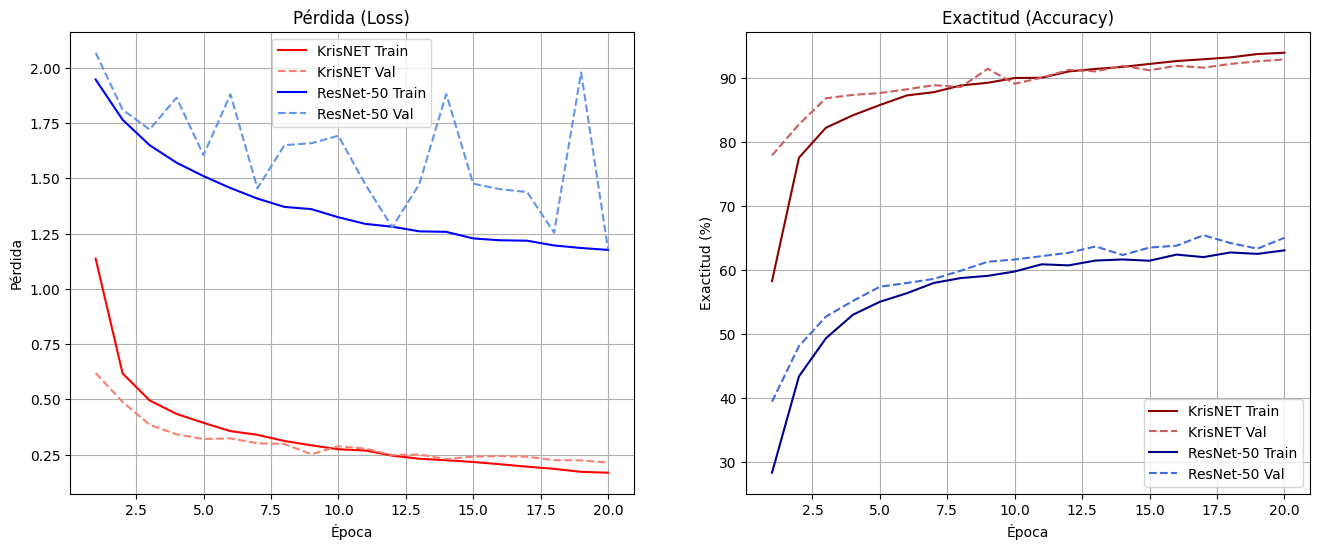

In [38]:
rango_epocas = range(1, epochs + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(rango_epocas, hist_kris['train_loss'], label='KrisNET Train', color='red')
ax1.plot(rango_epocas, hist_kris['val_loss'], label='KrisNET Val', color='salmon', linestyle='--')
ax1.plot(rango_epocas, hist_resnet['train_loss'], label='ResNet-50 Train', color='blue')
ax1.plot(rango_epocas, hist_resnet['val_loss'], label='ResNet-50 Val', color='cornflowerblue', linestyle='--')
ax1.set_title('Pérdida (Loss)')
ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(rango_epocas, hist_kris['train_acc'], label='KrisNET Train', color='darkred')
ax2.plot(rango_epocas, hist_kris['val_acc'], label='KrisNET Val', color='indianred', linestyle='--')
ax2.plot(rango_epocas, hist_resnet['train_acc'], label='ResNet-50 Train', color='darkblue')
ax2.plot(rango_epocas, hist_resnet['val_acc'], label='ResNet-50 Val', color='royalblue', linestyle='--')
ax2.set_title('Exactitud (Accuracy)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Exactitud (%)')
ax2.legend()
ax2.grid(True)

plt.savefig('convergencias.png', dpi=300, bbox_inches='tight')
plt.show()

### 7. Evaluación de Modelos (Prueba)


--- Métricas KrisNET ---
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       244
           1       0.96      0.99      0.98       624
           2       0.98      0.90      0.94       311
           3       0.79      0.87      0.83       579
           4       0.90      0.90      0.90       243
           5       0.93      0.71      0.81       284
           6       0.97      0.96      0.96       666
           7       1.00      1.00      1.00       470

    accuracy                           0.92      3421
   macro avg       0.92      0.90      0.91      3421
weighted avg       0.92      0.92      0.92      3421



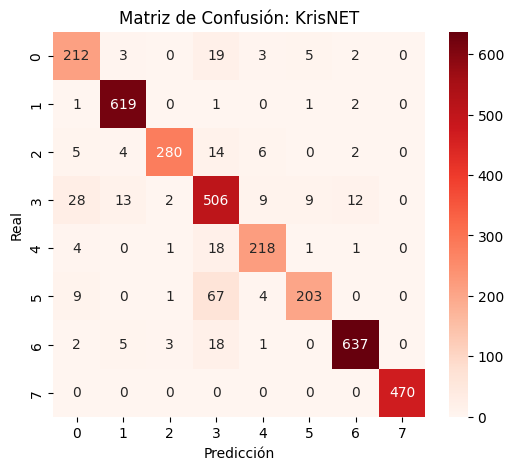


--- Métricas ResNet-50 ---
              precision    recall  f1-score   support

           0       0.67      0.32      0.44       244
           1       0.85      0.87      0.86       624
           2       0.61      0.48      0.54       311
           3       0.51      0.54      0.53       579
           4       0.57      0.54      0.55       243
           5       0.58      0.42      0.48       284
           6       0.62      0.77      0.69       666
           7       0.75      0.86      0.80       470

    accuracy                           0.66      3421
   macro avg       0.64      0.60      0.61      3421
weighted avg       0.66      0.66      0.65      3421



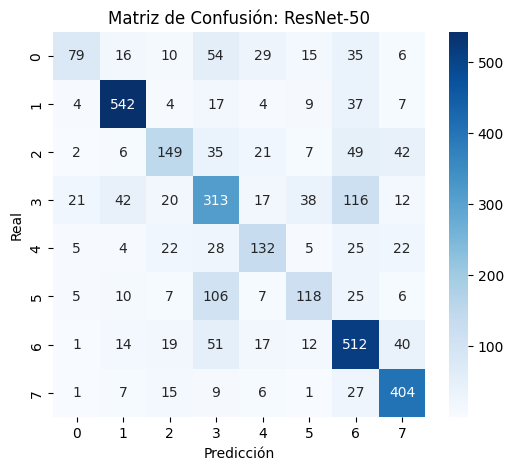

In [39]:
def evaluar(modelo, loader, nombre):
    modelo.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.squeeze(1).long().to(device)
            outputs = modelo(inputs)
            _, predicted = outputs.max(1)
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    
    print(f"\n--- Métricas {nombre} ---")
    print(classification_report(y_true, y_pred))
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Reds' if 'Kris' in nombre else 'Blues')
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.savefig(f'cm_{nombre.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

evaluar(modelo_kris, test_loader, "KrisNET")
evaluar(modelo_resnet, test_loader, "ResNet-50")